McKinley Martin

This script will explain how to create a simple scatter plot in Python using the same csv file as before. It will also show how to work out of functions instead of one long block of code: this strategy makes it easier for script modification, running isolated chunks, and running multiple files through the same script at once. Here, the file reading and data cleaning portion becomes a little bit more complicated than it is in R, but the plotting remains relatively straightforward. 

# Imports

We will start by running our imports: **matplotlib.pyplot** will be helpful for plotting, and **numpy** is efficient for working with numerical arrays. 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data Preparation

Next, we can read in the file and convert the data into a form that will be useful. This function takes in one file as an argument, and it will return a list of pH values and a list of salinity values as a tuple. Start by creating two empty lists: one for pH and one for salinity. You can then open the file in read ("r") mode and clean your data by line. 

The "for loop" will iterate over each line in the file. The .strip() command splits each line apart from one another, and the .split(",") command separatees each value by comma. The latter command is quite helpful for csv files, but you can also use .split() to split values by spaces if you are working in another file type. After these commands, python will create an individual list of the following format for each line: 
['Sample name', 'pH value', 'Salinity value']

Since the pH and salinity values are always in the same position, we can append them to their respective lists by index. Keep in mind that you will want to convert these strings to float values to make plotting easier later on. 

Outside of the for loop, return the two lists as a tuple. 

In [ ]:
def clean_data(filename):
    # initialize lists for pH and salinity values
    pH_values = []
    salinity_values = []
    # read in file
    file = open(filename, "r")
    # iterate over each line in the file, separate data points by comma
    for line in file:
        data_point = line.strip().split(",")
        # ignore lines with no data for one or both values
        if "ND" not in data_point:
            # append pH values to list as floats
            if data_point[1] != "pH":
                pH_values.append(float(data_point[1]))
            # append salinity values to list as floats
            if data_point[2] != "Salinity_dS_m":
                salinity_values.append(float(data_point[2]))
    return pH_values, salinity_values

# Plotting

Now we can create the plot! This function takes in our two lists as argument and shows a scatter plot. You can start by creating a NumPy array of each list, and then simply use the commands plt.scatter(x, y) and plt.show() to display your scatter plot. If you would like to add axis labels, use plt.xlabel("x axis label") and plt.ylabel("y label"). The function below also creates dashed vertical and horizontal lines for analysis of environmental conditions against experimental ones.

You can also modify the color and size of the data points in your plot if you would like. The following webpage includes more details on how to stylize in these ways: https://www.w3schools.com/python/matplotlib_scatter.asp 

In [ ]:
def create_plot(pH_values, salinity_values):
    # assign data to axes
    x = np.array(pH_values)
    y = np.array(salinity_values)
    # create dashed vertical lines at experimental pH values
    plt.axvline(x=5, linestyle="--", color="purple")
    plt.axvline(x=7, linestyle="--", color="blue")
    plt.axvline(x=9, linestyle="--", color="green")
    # create dashed horizontal lines at experimental salinity values
    plt.axhline(y=0, linestyle="--", color="purple")
    plt.axhline(y=23.4375, linestyle="--", color="blue")
    plt.axhline(y=46.875, linestyle="--", color="green")
    # create scatter plot
    plt.scatter(x, y, color = "black")
    # label axes and show plot
    plt.xlabel("pH")
    plt.ylabel("Salinity")
    plt.show()

# Main Functions

Main functions are a valuable tool for running your code. If you have a longer script and are working on just one function, you can update main to include only the portions that you actually want to call and evaluate the output for. This technique also works if you want to use the same general script for multiple files in the same run. This main function is pretty simple since we only have two functions, but it defines which file we are using and runs it through the script. After defining your main function, do not forget to call main() so that your code actually runs the way you would like it to. :)

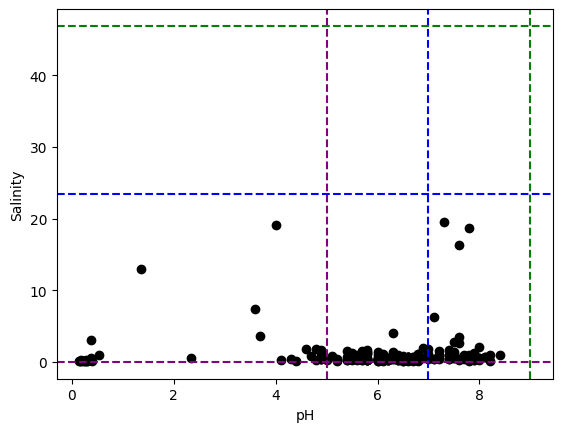

In [ ]:
def main():
    pH_values, salinity_values = clean_data("SoilChem_NMDS.csv")
    create_plot(pH_values, salinity_values)

main()